In [76]:
import os
import argparse
import yt
import glob
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import json
import math
from matplotlib.colors import LogNorm
from utils import *

In [46]:
# coefficient for cooling
limits = [0.0,      2.51e1,  3.98e1,  2.00e2,  1.0e3,   3.16e3,  6.31e3,  1.0e4,   1.70e4,   3.98e4, 7.94e4,  2.51e5,  5.62e5,  1.78e6, 2.75e6,   3.16e7, np.infty]
powers = [3.885,    1.50,    0.997,   0.431,   0.352,   0.152,   0.396,   13.8,    -0.216,   2.0,    0.01,    -2.0,    0.01,    -2.95,  -0.33,    0.50]
coef =   [1.095e-32,2.39e-29,1.52e-28,3.06e-27,5.28e-27,2.64e-26,3.13e-27,7.63e-81,1.479e-21,1.0e-31,5.50e-22,3.98e-11,1.15e-22,3.89e-4,5.188e-21,3.090e-27]

# kinetic/thermal energy constants
k = yt.physical_constants.kb
mu = 1.4
m_H = yt.physical_constants.mass_hydrogen

# heating/cooling constants
epsilon = 0.05
G_0 = 1.7
h_pe = 300
pc2cm = 3.086e18        # 1 pc in cm
Myr2sec = 3.1536e13     # 1 Myr in sec

In [47]:
p = PiecewisePowerlaw(limits=limits, powers=powers, coefficients=coef, norm=False)


def cooling_func(Tinp, dimensions=False):
    if dimensions:
        T = np.array(Tinp / yt.units.K)
        unit = yt.units.erg * yt.units.cm**3.0 * yt.units.s**(-1.0)
    else:
        T = np.array(Tinp)
        unit = 1
    return p(T) * unit

def energy_integral(energy, volume):
    # volume in pixel
    return energy * volume * (3.9*pc2cm) ** 3 * Myr2sec

In [22]:
timestamp = time_Myr2timestamp(210)

In [23]:
ds = yt.load(os.path.join('/home/joy0921/Desktop/Dataset/SB230/HDF5',
                     '{}{}'.format('sn34_smd132_bx5_pe300_hdf5_plt_cnt_0',
                                   timestamp)))

yt : [INFO     ] 2024-05-23 12:19:28,078 Parameters: current_time              = 6627195108709764.0
yt : [INFO     ] 2024-05-23 12:19:28,079 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-05-23 12:19:28,080 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-05-23 12:19:28,080 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-05-23 12:19:28,081 Parameters: cosmological_simulation   = 0


In [24]:
low_x0, low_y0, low_w, low_h, bottom_z, top_z = -500, -500, 1000, 1000, -500, 500
xlim = 256
ylim = 256
zlim= 256
center = [0, 0, 0] * yt.units.pc
z_range_scaled = (0, 256)

In [25]:
arb_center = ds.arr(center, 'code_length')
left_edge = arb_center + ds.quan(-500, 'pc')
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(xlim,ylim,zlim))


In [26]:
def read_mask_filenames(dataset_root, timestamp):
    mask_root = os.path.join(dataset_root, str(timestamp), "mask") 

    return sorted([os.path.join(mask_root, file) for file in os.listdir(mask_root)])

In [27]:
dataset_root = '../../Dataset/SB230'
mask_files = read_mask_filenames(dataset_root, timestamp)
timestamp_info = {}

In [87]:
mask_path = mask_files[25]
mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

In [88]:
mask_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [89]:
mask_boolean = mask_img == 255

In [114]:
z = int(mask_path.split("/")[-1].split(".")[-2])            # z in 256-pixel
z_pc = (z - 128) * 3.9          # converting z coordinate to pc

temp = obj["flash", "temp"][:, :, z][mask_boolean]
n = obj["flash", "dens"][:, :, z][mask_boolean] / (mu * m_H)

rho = obj["flash", "dens"][:, :, z][mask_boolean]
v_sq = (obj["flash", "velx"][:, :, z]**2 + obj["flash", "vely"][:, :, z]**2 + obj["flash", "velz"][:, :, z]**2)[mask_boolean]

cell_volume = obj["flash", "cell_volume"][:, :, z][mask_boolean]

In [121]:
z

141

In [118]:
heating_gamma = np.where(temp > 20000, 0,
                         epsilon * G_0 * np.exp(-np.abs(z_pc) / h_pe))        # Calculate heating_gamma based on temperature

heating_gamma_n = np.multiply(heating_gamma, n)                                                         # Multiply heating_gamma with n
#heating = np.sum(energy_integral(heating_gamma_n))


In [120]:
heating_gamma

array([7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
       7.17832568e-26, 7.17832568e-26, 7.17832568e-26, 7.17832568e-26,
      

In [119]:
heating_gamma_n

unyt_array([7.11986688e-26, 7.54434479e-26, 8.63530408e-26,
            9.34735764e-26, 9.76132629e-26, 1.02619344e-25,
            1.01610092e-25, 1.05026881e-25, 1.02151186e-25,
            7.78572553e-26, 8.04025937e-26, 9.11581965e-26,
            1.37818860e-25, 1.01861964e-25, 9.15559394e-26,
            9.78971314e-26, 1.02002067e-25, 1.07871390e-25,
            1.02922122e-25, 1.06142683e-25, 9.98659495e-26,
            9.63386537e-26, 9.29174054e-26, 4.17604026e-26,
            4.66075775e-26, 5.84621593e-26, 9.56722563e-26,
            9.01125755e-26, 7.97614590e-26, 5.93529063e-25,
            1.19586808e-24, 4.65182983e-25, 1.01942867e-25,
            9.42991212e-26, 1.01452442e-25, 1.08560709e-25,
            1.03379600e-25, 1.05156013e-25, 9.77532596e-26,
            9.33538109e-26, 8.96466399e-26, 8.60190844e-26,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
            0.00000000e+00, 0.00000000e+00, 4.39109369e-27,
            3.85992570e-26, 4.65874532e-

Text(0.5, 0, '$\\log T$')

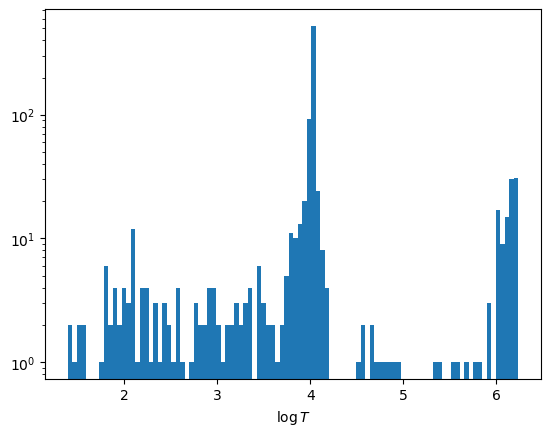

In [110]:
plt.hist(np.log10(temp.flatten()), bins=100)
plt.yscale('log')
plt.xlabel('$\log T$')

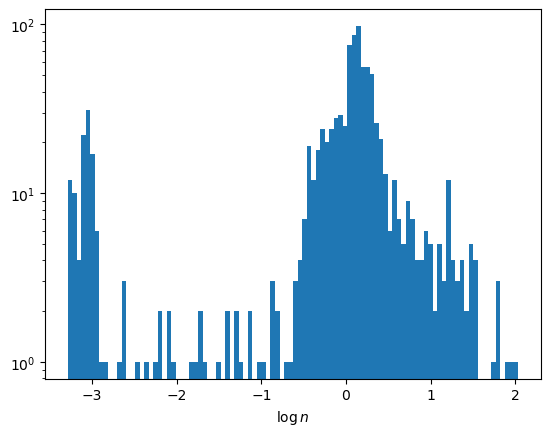

In [111]:
plt.hist(np.log10(n.flatten()), bins=100)
plt.xlabel('$\log n$')
plt.yscale('log')

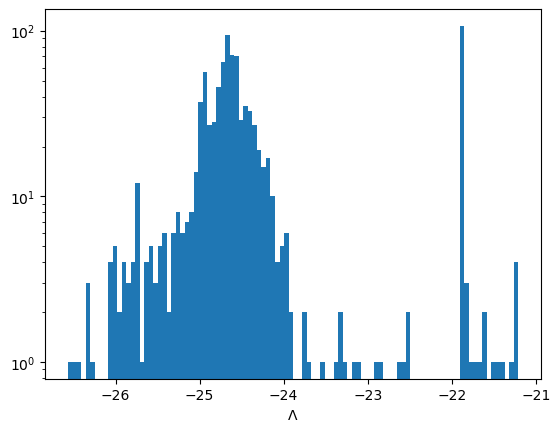

In [108]:
plt.hist(np.log10(cooling_func(temp.flatten())), bins=100)
plt.xlabel('$\Lambda$')
plt.yscale('log')

In [100]:
cooling = n**2 * cooling_func(temp, dimensions=True)

In [ ]:
net_cooling = n

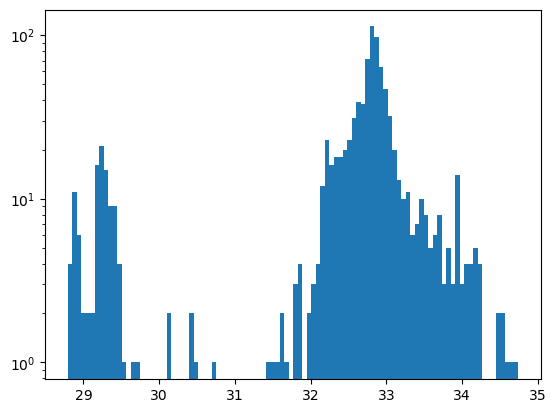

In [101]:
plt.hist(np.log10(cooling * cell_volume).flatten(), bins=100)
plt.yscale('log')

In [102]:
np.sum(cooling * cell_volume)

unyt_quantity(1.38338913e+36, 'erg/s')

Text(0, 0.5, '$\\log \\Lambda \\times V$')

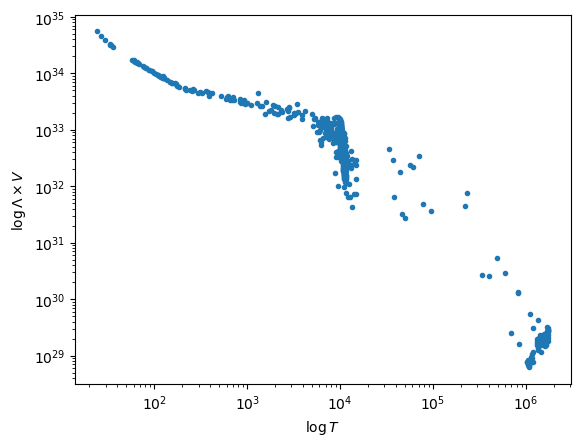

In [113]:
plt.plot(temp.flatten(), (cooling * cell_volume).flatten(),
        '.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\log T$')
plt.ylabel(r'$\log \Lambda \times V$')

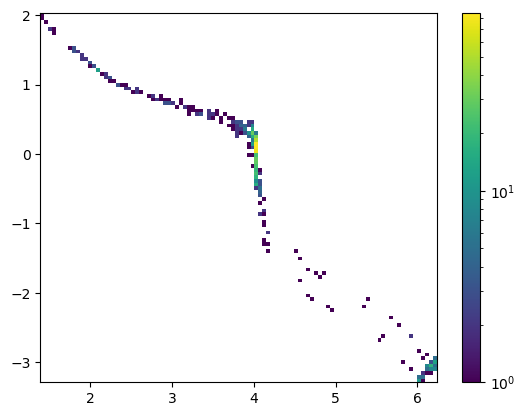

In [105]:
fig, ax = plt.subplots()
im = ax.hist2d(np.log10(temp.flatten()),
               np.log10(n.flatten()),
         bins=100, norm=LogNorm())
fig.colorbar(im[3])

In [ ]:
plt.hist()